## Setup

### Import Libraries

In [1]:
import numpy as np
import pandas as pd  
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler  
from sklearn.model_selection import train_test_split 
import torch  
import torch.nn as nn  
import torch.optim as optim

## Section 1: 


| Code | Description |
|---|---|
| `df = pd.read_csv('data.csv')` | Reads the data in `data.csv` into a pandas DataFrame and assigns it to the variable `df`. |

#### **Exercises**


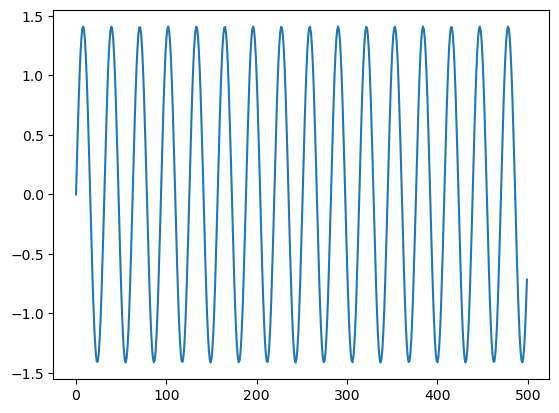

In [2]:
# Generate a sine wave  
times = np.linspace(0, 100, 500)   # 500 points between 0 and 100  
data = np.sin(times) # Create a sine wave  
 
z_data = (data-np.mean(data))/np.std(data)

plt.plot(z_data)


scaler = MinMaxScaler() 

df['value'] = scaler.fit_transform(df[['value']])  # Normalize values 
  
data = df['value'].values  # Convert to numpy array for sequence creation 


#### Create sequences and labels

In [22]:
def create_sequences(data, seq_length):  
  xs, ys = [], []  
  for i in range(len(data) - seq_length):  
    x = data[i:i+seq_length] # Sequence of length `seq_length`  
    y = data[i+seq_length] # Label is the next value  
    xs.append(x)  
    ys.append(y)  
  return np.array(xs), np.array(ys)  
 
SEQ_LENGTH = 20 # Number of past time steps to look at  

X, y = create_sequences(data, SEQ_LENGTH)

X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

train_len = int(0.8*X.shape[0])
val_len = int(0.1*X.shape[0])
test_len = X.shape[0] - train_len - val_len

X_train, x_val, x_test = torch.split(X, [train_len, val_len, test_len])
y_train, y_val, y_test = torch.split(y, [train_len, val_len, test_len])

X_train = X_train.unsqueeze(dim=-1)
X_train.shape

torch.Size([384, 20, 1])

In [30]:
rnn = nn.RNN(input_size=1, hidden_size=64, num_layers=1, batch_first=True)
out, _ = rnn(X_train)
pred = nn.Linear(64,1)(out[:,-1,:])
pred


tensor([[ 0.0939],
        [ 0.1111],
        [ 0.1250],
        [ 0.1351],
        [ 0.1410],
        [ 0.1426],
        [ 0.1398],
        [ 0.1327],
        [ 0.1215],
        [ 0.1068],
        [ 0.0889],
        [ 0.0686],
        [ 0.0468],
        [ 0.0241],
        [ 0.0017],
        [-0.0196],
        [-0.0390],
        [-0.0555],
        [-0.0686],
        [-0.0777],
        [-0.0825],
        [-0.0828],
        [-0.0785],
        [-0.0698],
        [-0.0572],
        [-0.0409],
        [-0.0218],
        [-0.0006],
        [ 0.0218],
        [ 0.0446],
        [ 0.0667],
        [ 0.0872],
        [ 0.1054],
        [ 0.1205],
        [ 0.1320],
        [ 0.1394],
        [ 0.1425],
        [ 0.1413],
        [ 0.1357],
        [ 0.1259],
        [ 0.1124],
        [ 0.0955],
        [ 0.0760],
        [ 0.0546],
        [ 0.0321],
        [ 0.0095],
        [-0.0123],
        [-0.0324],
        [-0.0501],
        [-0.0644],
        [-0.0750],
        [-0.0813],
        [-0.

In [32]:
y_train.shape

torch.Size([384])

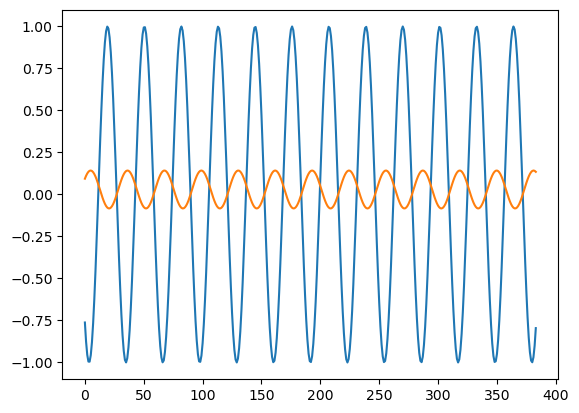

In [33]:
plt.plot(y_train)
plt.plot(pred[:,0].detach().numpy())


In [13]:
def create_sequences(data, seq_length):  
  xs, ys = [], []  
  for i in range(len(data) - seq_length):  
    x = data[i:i+seq_length] # Sequence of length `seq_length`  
    y = data[i+seq_length] # Label is the next value  
    xs.append(x)  
    ys.append(y)  
  return np.array(xs), np.array(ys)  
 
SEQ_LENGTH = 20 # Number of past time steps to look at  

X, y = create_sequences(data, SEQ_LENGTH)  

# Split data into train and test sets  
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)  

# Convert arrays to PyTorch tensors  
X_train = torch.Tensor(X_train).unsqueeze(-1) # Shape: (batch, seq, input_size)  
y_train = torch.Tensor(y_train)  
X_test = torch.Tensor(X_test).unsqueeze(-1)  
y_test = torch.Tensor(y_test) 
X_train.shape

torch.Size([384, 20, 1])

In [ ]:
class BasicRNN(nn.Module):  
  def __init__(self, input_size=1, hidden_size=64, num_layers=1):  
    super().__init__() 
    self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)  
    self.fc = nn.Linear(hidden_size, 1) # purpose of this seems to just be to go down to one output

  def forward(self, x): 
    out, _ = self.rnn(x)         # RNN output for all time steps 
    out = out[:, -1, :]          # Take output from the last time step 
    return self.fc(out)          # Pass through linear layer 
  
# Instantiate the model 
model = BasicRNN() 


#### Train

In [ ]:
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.01) 
  
EPOCHS = 100 

losses = [] 
  
for epoch in range(EPOCHS): 
  model.train() 
  output = model(X_train) 
  loss = criterion(output.squeeze(), y_train)  # Compute loss 

  optimizer.zero_grad() 
  loss.backward() 
  optimizer.step() 
  
  losses.append(loss.item()) 
  
  if (epoch + 1) % 10 == 0: 
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {loss.item():.4f}") 


Epoch [10/100], Loss: 0.1171
Epoch [20/100], Loss: 0.0178
Epoch [30/100], Loss: 0.0035
Epoch [40/100], Loss: 0.0015
Epoch [50/100], Loss: 0.0004
Epoch [60/100], Loss: 0.0001
Epoch [70/100], Loss: 0.0001
Epoch [80/100], Loss: 0.0001
Epoch [90/100], Loss: 0.0001
Epoch [100/100], Loss: 0.0000


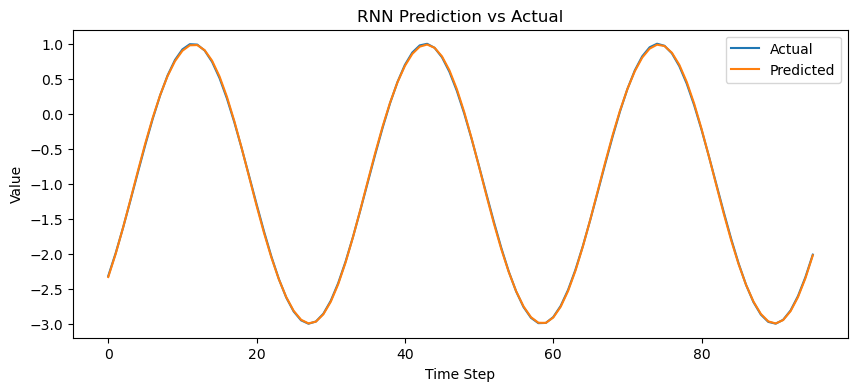

In [ ]:
model.eval()  
with torch.no_grad():  
  predictions = model(X_test).squeeze().numpy() # Predict on test set  

# Inverse transform to original scale  
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))  
predictions_inv = scaler.inverse_transform(predictions.reshape(-1, 1))  


# Plot actual vs predicted  
plt.figure(figsize=(10, 4))  
plt.plot(y_test_inv, label='Actual')  
plt.plot(predictions_inv, label='Predicted')  
plt.title("RNN Prediction vs Actual")  
plt.xlabel("Time Step")  
plt.ylabel("Value")  
plt.legend()  
plt.show() 
